# Ejercicio k-Nearest Neighbor

## App Reviews
En este ejercicio vas a trabajar con una base de datos de reviews de una aplicación. Entre los datos podemos encontrar el texto de la review, las estrellas, así como el sentimiento del comentario (si es algo bueno o malo).

El objetivo es montar un algoritmo de clasificación que prediga el rating, en función del sentimiento del comentario y la cantidad de palabras empleadas en el mismo. Para ello tendrás que utilizar un algoritmo de tipo KNN.

## Importamos las librerías que vamos a utilizar

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Leemos nuestro archivo de entrada `reviews_sentiment`

In [3]:
reviews = pd.read_csv('reviews_sentiment.csv', sep=';')

In [4]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Review Title    257 non-null    str    
 1   Review Text     257 non-null    str    
 2   wordcount       257 non-null    int64  
 3   titleSentiment  231 non-null    str    
 4   textSentiment   257 non-null    str    
 5   Star Rating     257 non-null    int64  
 6   sentimentValue  257 non-null    float64
dtypes: float64(1), int64(2), str(4)
memory usage: 14.2 KB


In [35]:
reviews[["wordcount", "sentimentValue", "Review Text", "Star Rating"]].head(-20)

,wordcount,sentimentValue,Review Text,Star Rating
0,23,-0.486389,Hola desde hace algo más de un mes me pone sin...,1
1,20,-0.586187,Han mejorado la apariencia pero no,1
2,4,-0.602240,Andres e puto amoooo,1
3,17,-0.616271,Me gustana mas la version anterior esta es mas...,1
4,6,-0.651784,Sin ser la biblia.... Esta bien,1
...,...,...,...,...
232,5,1.496927,De momento va todo genial,5
233,9,1.527797,estupenda ami me va genial gracias y sigan mej,5
234,2,1.593301,Muy bien,5
235,2,1.593301,Muy bien...,5


Parece que las reviews negativas tienen menos palabras y que las positivas tienen el sentimentvalue más alto.

Para facilitar el ejercicio, las columnas que utilizaremos serán: wordcount con la cantidad de palabras utilizadas y sentimentValue con un valor entre -4 y 4 que indica si el comentario fue valorado como positivo o negativo

Nuestras etiquetas, serán las estrellas que dieron los usuarios a la app, que son valores discretos del 1 al 5

In [5]:
# estas son las variables predictoras
X = reviews[['wordcount', 'sentimentValue']]

# esta es la variable a predecir
y = reviews['Star Rating']

print(X.shape)
print(y.shape)

(257, 2)
(257,)


## Rápidas visualizaciones y análisis
Al menos realiza un análisis univariante y representa la distribución del rating. Realiza otras visualizaciones para ver la relación de tus datos.

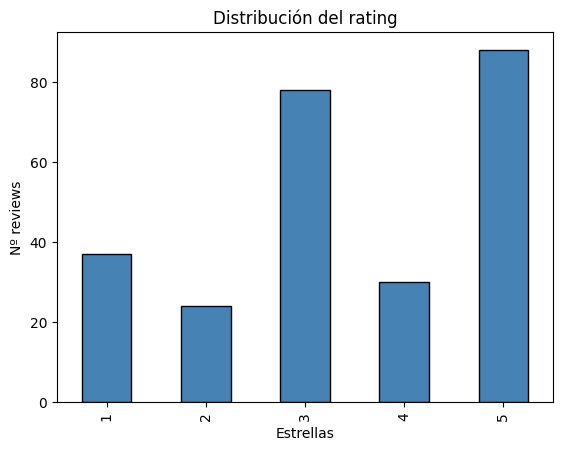

In [8]:
# Visualización de la distribución del rating
reviews['Star Rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribución del rating')
plt.xlabel('Estrellas')
plt.ylabel('Nº reviews');

Parece que este es un dataset bastante desbalanceado. Las clases 3 y 5 dominan, mientras que 2 y 4 tienen muy pocas muestras.

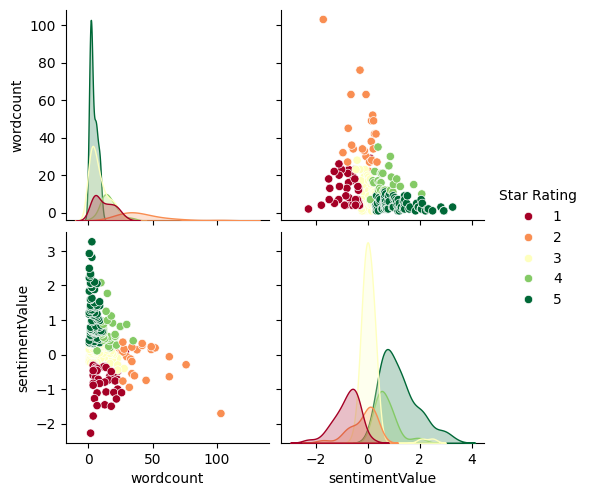

In [13]:
# visualización de la relación entre las variables predictoras y el rating
sns.pairplot(reviews[['wordcount', 'sentimentValue', 'Star Rating']], hue='Star Rating', palette='RdYlGn');

Parece que "sentimentValue" separa bien las clases, ya que los puntos rojos (1 estrella) se concentran en valores negativos y los puntos verdes (4-5) en valores positivos. Por otro lado, la variable "wordcount" apenas separa, ya que todas las clases se apilan en valores bajo. Esta última, seguramente sea la variable menos útil del modelo.

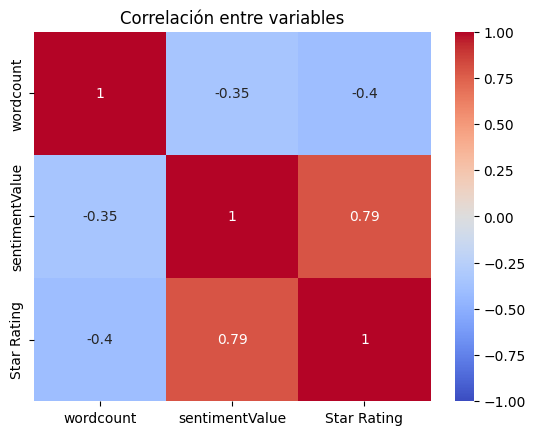

In [ ]:
# visualización de la correlación entre las variables predictoras y el rating
sns.heatmap(reviews[['wordcount', 'sentimentValue', 'Star Rating']].corr(), annot=True, cmap='coolwarm', vmin=-1)
plt.title('Correlación entre variables');

A modo de resumen, el modelo va a tirar principalmente de "sentimentValue", mientras que "wordcount" ayuda algo, pero poco.

## Preparamos el dataset
Divide en train/test y escala las features en el rango [0, 1].

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# divido los datos en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

# hago el escalado con MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Creamos el Modelo
Entrena con un KNN y evalúa el error en train y en test

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# declaro el modelo KNN
modelo_knn = KNeighborsClassifier(n_neighbors=5)
# entreno el modelo con los datos escalados
modelo_knn.fit(X_train_scaled, y_train)

accuracy_train = modelo_knn.score(X_train_scaled, y_train)
accuracy_test = modelo_knn.score(X_test_scaled, y_test)

print(f"Accuracy Train: {accuracy_train:.2f}")
print(f"Accuracy Test:  {accuracy_test:.2f}")

Accuracy Train: 0.94
Accuracy Test:  0.85


Se puede decir que son muy buenos resultados para empezar:

* Accuracy Train de 0.94, significa que el modelo aprende bien con los datos de entrenamiento.
* Accuracy Test de 0.85, significa que generaliza bastante bien.

## Evalúa tu modelo

In [18]:
# hago las predicciones con el modelo entrenado
predicciones = modelo_knn.predict(X_test_scaled)
predicciones

array([3, 5, 5, 3, 5, 1, 3, 3, 3, 3, 3, 5, 2, 2, 5, 4, 5, 5, 2, 3, 3, 1,
       5, 3, 5, 5, 4, 2, 1, 2, 2, 3, 5, 3, 1, 1, 1, 3, 5, 1, 5, 3, 1, 2,
       5, 5, 3, 3, 3, 3, 5, 4])

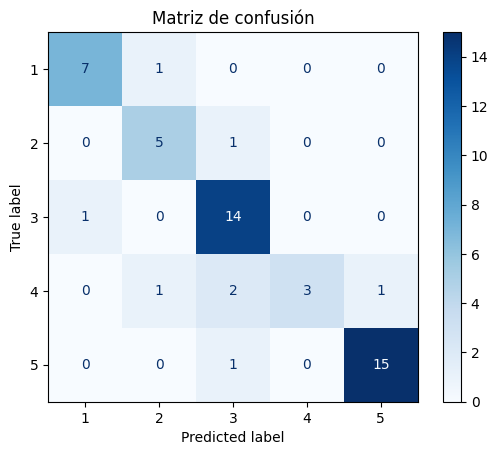

In [21]:
# creo la matrix de confusión y la visualizo
cm = confusion_matrix(y_test, predicciones)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4,5])
disp.plot(cmap='Blues')
plt.title('Matriz de confusión');


El modelo funciona bien, ya que en la diagonal es donde se concentran los valores. Parece que la clase 4 es la que peor clasifica, ya que solo acierta 3 de 7. Esto era de esperar por ser la clase con menos muestras en el dataset.

Por otro lado, parece que los errores son entre clases adyacentes. Por ejemplo,  cuando falla, confunde 1 con 2, 3 con 4, etc. Es decir, nunca predice un 1 como 5 ni al revés. 

In [23]:
from sklearn.metrics import classification_report
# imprimo el reporte de clasificación
print(classification_report(y_test, predicciones))

              precision    recall  f1-score   support

           1       0.88      0.88      0.88         8
           2       0.71      0.83      0.77         6
           3       0.78      0.93      0.85        15
           4       1.00      0.43      0.60         7
           5       0.94      0.94      0.94        16

    accuracy                           0.85        52
   macro avg       0.86      0.80      0.81        52
weighted avg       0.86      0.85      0.84        52



Aquí lo más llamativo está en la clase 4. Tienen una precision de 1 pero una recall de 0,43. Es decir, que cuando predice 4 estrellas nunca se equivoca, pero se le escapan muchos casos 4 estrellas, que los clasifica como 3. 

## ¿Cómo obtener el mejor valor de k? Crea y evalúa nuevos modelos
¿Qué valor de k maximiza el accuracy? Representa todas las iteraciones en un scatterplot -> k vs accuracy

In [24]:
from sklearn.model_selection import GridSearchCV

# defino los valores de k que se irán probando
parametros_grid = {'n_neighbors': range(1, 50)}

# hago un gridsearch con validación cruzada para encontrar el mejor k
modelo_grid = GridSearchCV(KNeighborsClassifier(), parametros_grid, cv=5, scoring='accuracy')
modelo_grid.fit(X_train_scaled, y_train)

# imprimo el mejor k y su accuracy
print(f"Mejor k: {modelo_grid.best_params_}")
print(f"Mejor accuracy CV: {modelo_grid.best_score_:.2f}")

Mejor k: {'n_neighbors': 4}
Mejor accuracy CV: 0.86


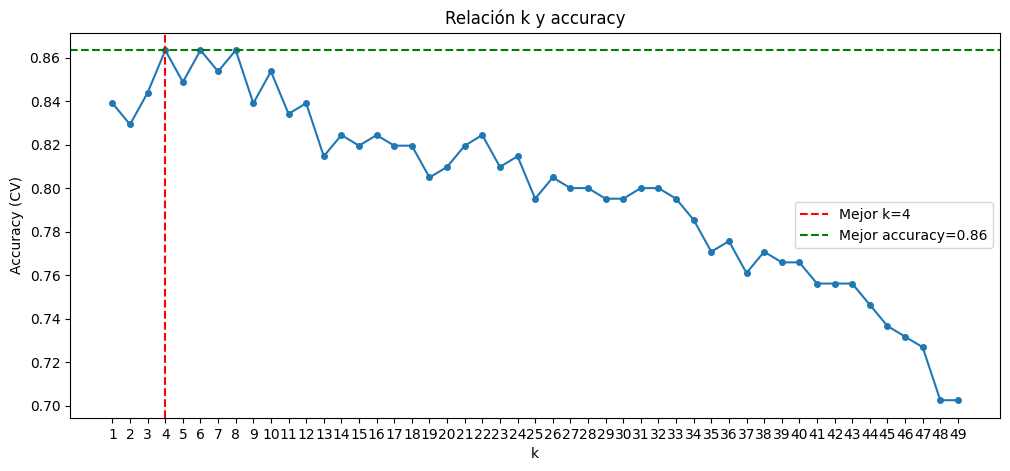

In [28]:
# convierto los resultados del GridSearch a un dataframe
resultados = pd.DataFrame(modelo_grid.cv_results_)
# busca el valor máximo de la columna "mean_test_score" del dataframe, es decir, el accuracy 
# más alto de todos los k probados. En este caso, devuelve 0.86
mejor_accuracy = resultados['mean_test_score'].max()
# busca en qué fila está ese accuracy máximo y devuelve el k correspondiente
mejor_k = resultados.loc[resultados['mean_test_score'].idxmax(), 'param_n_neighbors']

# visualizo la relación entre k y el accuracy
plt.figure(figsize=(12, 5))
plt.plot(resultados['param_n_neighbors'], resultados['mean_test_score'], marker='o', markersize=4)
plt.axvline(x=mejor_k, color='red', linestyle='--', label=f'Mejor k={mejor_k}')
plt.axhline(y=mejor_accuracy, color='green', linestyle='--', label=f'Mejor accuracy={mejor_accuracy:.2f}')
plt.xlabel('k')
plt.ylabel('Accuracy (CV)')
plt.title('Relación k y accuracy')
plt.xticks(range(1, 50))
plt.legend()
plt.show()

## Predice con nuevos datos.
Ejemplo: supongamos que nos llega una review de 5 palabras y sentimiento 1

In [37]:
# creo un dataframe con una nueva review de 5 palabras y sentimiento 1
nueva_review = pd.DataFrame({'wordcount': [5], 'sentimentValue': [1]})

# escalo con el mismo scaler de antes
nueva_review_scaled = scaler.transform(nueva_review)

# realizo la predicción con el mejor modelo encontrado en el GridSearch
prediccion = modelo_grid.best_estimator_.predict(nueva_review_scaled)

#imprimo la predicción
print(f"Predicción de rating: {prediccion[0]} estrellas")

Predicción de rating: 5 estrellas
